<a href="https://colab.research.google.com/github/shahriarSwanon/Image-classification/blob/main/Animal_Classifier_Model2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

In [2]:
# Clone the repository
!git clone https://github.com/shahriarSwanon/Image-classification.git


Cloning into 'Image-classification'...
remote: Enumerating objects: 545, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 545 (delta 0), reused 0 (delta 0), pack-reused 544 (from 2)
Receiving objects: 100% (545/545), 607.93 MiB | 43.25 MiB/s, done.
Updating files: 100% (534/534), done.


In [3]:
!ls -la Image-classification/

total 88
drwxr-xr-x 4 root root  4096 Mar 15 18:14  .
drwxr-xr-x 1 root root  4096 Mar 15 18:13  ..
-rw-r--r-- 1 root root 67676 Mar 15 18:14  animal_classifier_project.ipynb
drwxr-xr-x 7 root root  4096 Mar 15 18:14 'Animal Dataset'
drwxr-xr-x 8 root root  4096 Mar 15 18:14  .git
-rw-r--r-- 1 root root   365 Mar 15 18:14  README.md


In [4]:
print("="*50)
print("STEP 4: IMPORTING LIBRARIES")
print("="*50)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

print("✅ TensorFlow version:", tf.__version__)
print("✅ Keras version:", keras.__version__)
print("✅ NumPy version:", np.__version__)
print("✅ All libraries imported successfully!")

STEP 4: IMPORTING LIBRARIES
✅ TensorFlow version: 2.19.0
✅ Keras version: 3.13.2
✅ NumPy version: 2.0.2
✅ All libraries imported successfully!


In [6]:
# Define the dataset path
import os

dataset_path = '/content/Image-classification/Animal Dataset'
print(f"Dataset path set to: {dataset_path}")

# Check if the path exists
if os.path.exists(dataset_path):
    print("✅ Path exists!")
    print("\nContents of Animal Dataset folder:")
    !ls -la "{dataset_path}"
else:
    print("❌ Path does not exist!")
    print("Current directory contents:")
    !ls -la /content/

Dataset path set to: /content/Image-classification/Animal Dataset
✅ Path exists!

Contents of Animal Dataset folder:
total 36
drwxr-xr-x 7 root root  4096 Mar 15 18:14 .
drwxr-xr-x 4 root root  4096 Mar 15 18:14 ..
drwxr-xr-x 2 root root  4096 Mar 15 18:14 cat
drwxr-xr-x 2 root root  4096 Mar 15 18:14 cow
drwxr-xr-x 2 root root  4096 Mar 15 18:14 dog
drwxr-xr-x 2 root root 12288 Mar 15 18:14 lamb
drwxr-xr-x 2 root root  4096 Mar 15 18:14 zebra


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("="*50)
print("STEP 5: SETTING UP DATA GENERATORS")
print("="*50)

# Parameters
IMG_SIZE = 224
BATCH_SIZE = 32
class_names = ['cat', 'cow', 'dog', 'lamb', 'zebra']

print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Classes: {class_names}")

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Validation data generator
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

print("\nCreating training generator...")
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

print("\nCreating validation generator...")
validation_generator = validation_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("\n✅ Class mapping:")
for class_name, class_index in train_generator.class_indices.items():
    print(f"   {class_name} -> {class_index}")

STEP 5: SETTING UP DATA GENERATORS
Image Size: 224x224
Batch Size: 32
Classes: ['cat', 'cow', 'dog', 'lamb', 'zebra']

Creating training generator...
Found 427 images belonging to 5 classes.

Creating validation generator...
Found 105 images belonging to 5 classes.

✅ Class mapping:
   cat -> 0
   cow -> 1
   dog -> 2
   lamb -> 3
   zebra -> 4


STEP 6: DISPLAYING SAMPLE IMAGES


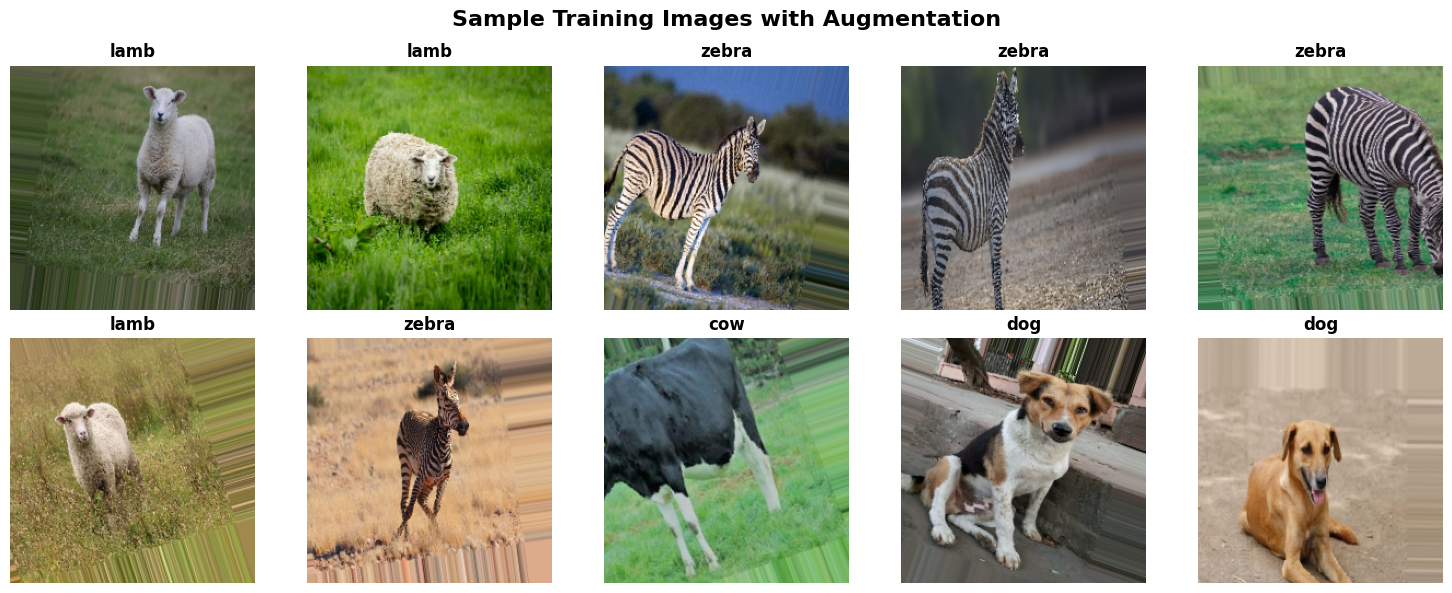

✅ Displayed 10 sample images from training set
Image shape: (224, 224, 3)


In [8]:
print("="*50)
print("STEP 6: DISPLAYING SAMPLE IMAGES")
print("="*50)

# Get a batch of images
images, labels = next(train_generator)

# Create a figure
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

# Plot 10 images
for i in range(10):
    axes[i].imshow(images[i])
    class_idx = np.argmax(labels[i])
    class_name = class_names[class_idx]
    axes[i].set_title(f"{class_name}", fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Sample Training Images with Augmentation", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✅ Displayed 10 sample images from training set")
print(f"Image shape: {images[0].shape}")  # Shows (224, 224, 3)

In [10]:
print("="*50)
print("STEP 7: BUILDING TRANSFER LEARNING MODEL (VGG16)")
print("="*50)

from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Load pre-trained VGG16
print("Loading VGG16 pre-trained weights...")
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model layers
base_model.trainable = False
print("✅ Base model frozen (layers not trainable)")

# Build complete model
model = tf.keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', name='dense_1'),
    layers.Dropout(0.5, name='dropout_1'),
    layers.Dense(128, activation='relu', name='dense_2'),
    layers.Dropout(0.3, name='dropout_2'),
    layers.Dense(5, activation='softmax', name='output_layer')
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✅ Model compiled successfully!")
print("\n" + "="*50)
print("MODEL SUMMARY")
print("="*50)
model.summary()

print("\n" + "="*50)
print("✅ Model built successfully! Ready for training.")
print("="*50)

STEP 7: BUILDING TRANSFER LEARNING MODEL (VGG16)
Loading VGG16 pre-trained weights...
✅ Base model frozen (layers not trainable)

✅ Model compiled successfully!

MODEL SUMMARY


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,557 (56.76 MB)

 Trainable params: 164,869 (644.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


✅ Model built successfully! Ready for training.


In [11]:
print("="*50)
print("STEP 8: SETTING UP TRAINING CALLBACKS")
print("="*50)

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Callbacks for better training
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1,
        mode='min'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=0.00001,
        verbose=1,
        mode='min'
    ),
    ModelCheckpoint(
        'best_animal_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    )
]

print("✅ EarlyStopping: Will stop if validation loss doesn't improve for 5 epochs")
print("✅ ReduceLROnPlateau: Will reduce learning rate by 0.2x if loss plateaus for 3 epochs")
print("✅ ModelCheckpoint: Will save best model based on validation accuracy")

# Calculate steps
steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = validation_generator.samples // BATCH_SIZE

print(f"\n📊 Training steps per epoch: {steps_per_epoch}")
print(f"📊 Validation steps per epoch: {validation_steps}")
print(f"📊 Total training samples: {train_generator.samples}")
print(f"📊 Total validation samples: {validation_generator.samples}")

STEP 8: SETTING UP TRAINING CALLBACKS
✅ EarlyStopping: Will stop if validation loss doesn't improve for 5 epochs
✅ ReduceLROnPlateau: Will reduce learning rate by 0.2x if loss plateaus for 3 epochs
✅ ModelCheckpoint: Will save best model based on validation accuracy

📊 Training steps per epoch: 13
📊 Validation steps per epoch: 3
📊 Total training samples: 427
📊 Total validation samples: 105


In [12]:
print("="*50)
print("STEP 9: TRAINING THE MODEL")
print("="*50)
print("Training started... Press Ctrl+C to stop early")
print("-" * 50)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=20,  # You can increase this if needed
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

print("-" * 50)
print("✅ Training completed!")

STEP 9: TRAINING THE MODEL
Training started... Press Ctrl+C to stop early
--------------------------------------------------
Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1874 - loss: 1.7988
Epoch 1: val_accuracy improved from None to 0.32292, saving model to best_animal_model.h5



Epoch 1: finished saving model to best_animal_model.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - accuracy: 0.1823 - loss: 1.7559 - val_accuracy: 0.3229 - val_loss: 1.5259 - learning_rate: 0.0010
Epoch 2/20
 1/13 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.1875 - loss: 1.7170

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.32292 to 0.34375, saving model to best_animal_model.h5



Epoch 2: finished saving model to best_animal_model.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 411ms/step - accuracy: 0.1875 - loss: 1.7170 - val_accuracy: 0.3438 - val_loss: 1.5149 - learning_rate: 0.0010
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2490 - loss: 1.5760
Epoch 3: val_accuracy improved from 0.34375 to 0.64583, saving model to best_animal_model.h5


...


Epoch 6: finished saving model to best_animal_model.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 412ms/step - accuracy: 0.3125 - loss: 1.5275 - val_accuracy: 0.7292 - val_loss: 1.2972 - learning_rate: 0.0010
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4758 - loss: 1.2934
Epoch 7: val_accuracy did not improve from 0.72917
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.4582 - loss: 1.2908 - val_accuracy: 0.6771 - val_loss: 1.1612 - learning_rate: 0.0010
Epoch 8/20
 1/13 ━━━━━━━━━━━━━━━━━━━━ 2s 211ms/step - accuracy: 0.4688 - loss: 1.4242
Epoch 8: val_accuracy did not improve from 0.72917
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 424ms/step - accuracy: 0.4688 - loss: 1.4242 - val_accuracy: 0.6667 - val_loss: 1.1571 - learning_rate: 0.0010
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4848 - loss: 1.2730
Epoch 9: val_accuracy improved from 0.72917 to 0.78125, saving model to best_animal_model.h5



Epoch 9: finished saving model to best_animal_model.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.5089 - loss: 1.2182 - val_accuracy: 0.7812 - val_loss: 1.0286 - learning_rate: 0.0010
Epoch 10/20
 1/13 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - accuracy: 0.5312 - loss: 1.0927
Epoch 10: val_accuracy did not improve from 0.78125
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 445ms/step - accuracy: 0.5312 - loss: 1.0927 - val_accuracy: 0.7812 - val_loss: 1.0212 - learning_rate: 0.0010
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5596 - loss: 1.1294
Epoch 11: val_accuracy did not improve from 0.78125
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.5899 - loss: 1.0903 - val_accuracy: 0.7604 - val_loss: 0.9107 - learning_rate: 0.0010
Epoch 12/20
 1/13 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - accuracy: 0.6562 - loss: 0.9284
Epoch 12: val_accuracy did not improve from 0.78125
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 444ms/step - accuracy: 0.6562 - loss: 0.9284 - val_accuracy: 0.7604 - val_loss: 0


Epoch 17: finished saving model to best_animal_model.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.7241 - loss: 0.7974 - val_accuracy: 0.8021 - val_loss: 0.6657 - learning_rate: 0.0010
Epoch 18/20
 1/13 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - accuracy: 0.8125 - loss: 0.7454
Epoch 18: val_accuracy did not improve from 0.80208
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 734ms/step - accuracy: 0.8125 - loss: 0.7454 - val_accuracy: 0.7812 - val_loss: 0.6677 - learning_rate: 0.0010
Epoch 19/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7456 - loss: 0.7961
Epoch 19: val_accuracy improved from 0.80208 to 0.81250, saving model to best_animal_model.h5



Epoch 19: finished saving model to best_animal_model.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.7620 - loss: 0.7395 - val_accuracy: 0.8125 - val_loss: 0.6151 - learning_rate: 0.0010
Epoch 20/20
 1/13 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - accuracy: 0.8125 - loss: 0.5599
Epoch 20: val_accuracy improved from 0.81250 to 0.82292, saving model to best_animal_model.h5



Epoch 20: finished saving model to best_animal_model.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 405ms/step - accuracy: 0.8125 - loss: 0.5599 - val_accuracy: 0.8229 - val_loss: 0.6038 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 20.
--------------------------------------------------
✅ Training completed!


STEP 10: PLOTTING TRAINING RESULTS


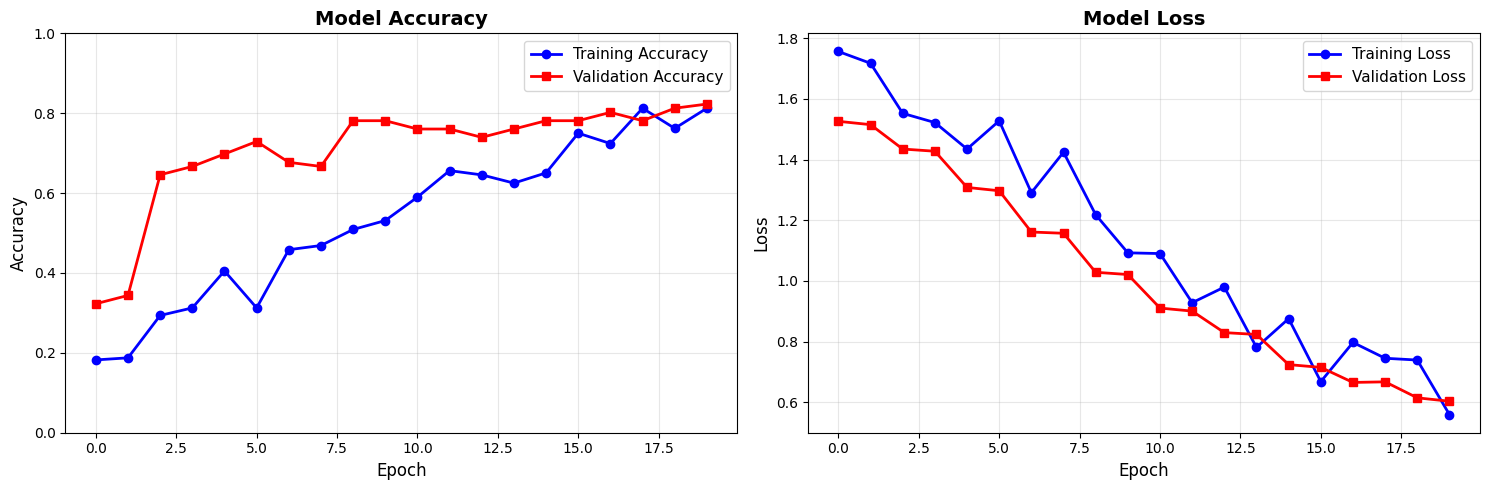

🏆 Best Validation Accuracy: 82.29% at epoch 20
📊 Final Validation Accuracy: 82.29%
📊 Final Validation Loss: 0.6038


In [13]:
print("="*50)
print("STEP 10: PLOTTING TRAINING RESULTS")
print("="*50)

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracy
ax1.plot(history.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2, marker='o')
ax1.plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2, marker='s')
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# Plot loss
ax2.plot(history.history['loss'], 'b-', label='Training Loss', linewidth=2, marker='o')
ax2.plot(history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2, marker='s')
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best results
best_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_acc) + 1
final_acc = history.history['val_accuracy'][-1]
final_loss = history.history['val_loss'][-1]

print(f"🏆 Best Validation Accuracy: {best_acc:.2%} at epoch {best_epoch}")
print(f"📊 Final Validation Accuracy: {final_acc:.2%}")
print(f"📊 Final Validation Loss: {final_loss:.4f}")